Ce fichier test la méthode de classification d'un seuil AC > 0. Le modèle prédit pour 1 sec un "mouvement" (AC>0) ou un "non mouvement" (AC = 0), puis ces résultats sont comparés aux annotations disponnibles dans "C:/Users/roman/Documents/BEaCHILD/X_et_Y" (correspondent aux annotations RCT1 de CAP). Le modèle est évalué par le score F1, le score d'accuracy et l'analyse de la matrice de confusion.

Les étapes réalisées sont les suivantes:
1. Lecture des fichiers .csv (données des capteurs), conversion dans la bonne unité et transformation en AC
2. Récuperation des annotations
3. Association des annotations des fichiers excel aux valeurs des fichiers .csv (fait dans 1. et 2.)
4. Application du seuil : comparaison à 0
5. Analyser des résultats (matrices de confusion, accuracy score)

Plusieurs tests ont été effectués pour pallier le déséquilibre des classes 'mouvement' et 'non mouvement':
- équilibrage des données (séléction d'une partie (aléatoire) des données de la classe majoritaire),
- génération de nouvelles données ressemblant aux données de la classe minoritaire avec 3 méthodes : RandomOverSampler, SMOTE et ADASYN (meilleurs scores obtenus avec RandomOverSampling)


In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from agcounts_filter import convert_AC
from datetime import datetime
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

1-3 Récupération de X et Y 

In [34]:
temps_depart = datetime.now()

folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

#////////////////////////////// Attention : le fichier LW est défini comme le dominant ////////////////////////////////

# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []
idx_X_non_dom = 0
idx_X_dom = 0
idx_Y_dom = 0
idx_Y_non_dom = 0

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []


#Parcourir les fichiers CSV
for file in folder[4:7]: # //////////////////////// Ajuster les indices pour choisir le fichier à analyser
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":
        # Récupération des noms des colonnes pour pouvoir lire le fichier (pas le m^me pour tous)
        csv_file_column = pd.read_csv(folder_path + "/" + file, skiprows=5, sep = ',', low_memory = False)
        lst_column = list(csv_file_column)

        # Les fichiers n'ont pas tous le même nombre de données
        if lst_column == ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"]:
            # Lecture des données des capteurs
            data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    
        elif lst_column == ['Time', 'Gyro X', 'Gyro Y', 'Gyro Z', 'Accel X', 'Accel Y', 'Accel Z', 'Quat W', 'Quat X', 'Quat Y', 'Quat Z', 'Unnamed: 11']:
            # Lecture des données des capteurs
            data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ['Time', 'Gyro X', 'Gyro Y', 'Gyro Z', 'Accel X', 'Accel Y', 'Accel Z', 'Quat W', 'Quat X', 'Quat Y', 'Quat Z', 'Unnamed: 11'])    
        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_AC = dom_AC["AC"].tolist() 
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-7:-4] == "dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                start_dom = int(round(float(my_sheet.cell(label.row,13).value))) - 1
                # Décalage pour synchroniser X et Y
                for decalage in range(start_dom):
                    Y_dom.append(None)
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                start_non_dom = int(round(float(my_sheet.cell(label.row,13).value))) - 1
                # Décalage pour synchroniser X et Y
                for decalage in range(start_non_dom):
                    Y_non_dom.append(None)
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_dom.append(None) 
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                for nb_sec in range(nb_repetitions): 
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[3:13] == "sédentaire" :
                        Y_dom.append("non mouvement")
                    elif label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom.append(None) 

                # Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None) #.append("décalage annotations")

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                for nb_sec in range(nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    if label.value[3:13] == "sédentaire" :
                        Y_non_dom.append("non mouvement")
                    elif label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_non_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)

                # Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row

        # CROPER X A LA LONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom) ] 
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom) ]
        Y_non_dom = Y_non_dom[:len(X_non_dom) ]

print(len(X_dom))
print(len(X_non_dom))

On est dans le fichier : Data_11_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_X.xlsx
3642
3642


Brouillon équilibrage

In [35]:
# Convertir en array pour faciliter le filtrage
X_array = np.array(X_dom)
Y_array = np.array(Y_dom)
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_None = Y_array != None
# Appliquer le masque
X_clean = X_array[mask_None]
Y_clean = Y_array[mask_None]

#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array
# Compter les "non mouvement"
n_non_mvt = np.sum(Y_clean == 'non mouvement')
n_mvt = np.sum(Y_clean == 'mouvement')
# Sélectionner les indices dans l’ordre original
indices_mvt = np.where(Y_clean == 'mouvement')[0]
indices_non_mvt = np.where(Y_clean == 'non mouvement')[0]
# Si plus de mouvement
if n_non_mvt < n_mvt:
    # Garder les premiers `mouvement` rencontrés dans l'ordre
    indices_mvt_crop = indices_mvt[:n_non_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final = sorted(np.concatenate((indices_non_mvt, indices_mvt_crop)))
# Si plus de non mouvement
elif n_mvt < n_non_mvt :
    # Garder les premiers `non mouvement` rencontrés dans l'ordre
    indices_non_mvt_crop = indices_non_mvt[:n_mvt]
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final = sorted(np.concatenate((indices_mvt, indices_non_mvt_crop)))
# Réorganise X et Y
X_balanced = X_clean[indices_final]
Y_balanced = Y_clean[indices_final]

# Aplatir les données (mettre au bon format pour les modèles)
X_flat = np.vstack(X_balanced)  # (n_total_samples, n_features)
Y_flat = np.hstack(Y_balanced)  # (n_total_samples,)

Nettoyage et équilibrage

In [25]:
"""lst_X_members = [X_dom, X_non_dom]
lst_Y_members = [Y_dom, Y_non_dom]
balanced_X_members = []
balanced_Y_members = []

for idx_member in range(2):
    # ********************************** Préparation des données (équilibre, suppression des None,) *****************************************************************
    # Convertir en array pour faciliter le filtrage
    X_array = np.array(lst_X_members[idx_member])
    Y_array = np.array(lst_Y_members[idx_member])
    # Créer un masque pour garder uniquement les étiquettes valides (différent de None)
    mask_None = Y_array != None
    # Appliquer le masque
    X_clean = X_array[mask_None]
    Y_clean = Y_array[mask_None]

    # Aplatir les données (mettre au bon format pour les modèles)
    X_flat = np.vstack(X_clean)  # (n_total_samples, n_features)
    Y_flat = np.hstack(Y_clean)  # (n_total_samples,)

    # Equilibrer en sur échantillonant la classe minoritaire. Test de : RandomOverSampler (créer des points à coté des points existants), SMOTE (créer de nouveaux points entre les points existants), ADASYN (créer de nouveaux points entre les points existants mal classifiés).

    # RandomOverSampling
    #ros = RandomOverSampler(random_state=0)
    #X_balanced, Y_balanced = ros.fit_resample(X_flat, Y_flat)

    # SMOTE
    #X_balanced, Y_balanced = SMOTE().fit_resample(X_flat, Y_flat)

    # ADASYN
    #X_balanced, Y_balanced = ADASYN().fit_resample(X_flat, Y_flat)

    # Enregistrer les valeurs
    #balanced_X_members.append(X_balanced) #balanced_X_members.append(X_flat) # 
    #balanced_Y_members.append(Y_balanced) # balanced_Y_members.append(Y_flat) # 
   """
"""
    # Vérifier que les classes sont bien équilibrées
    print(sorted(Counter(Y_balanced).items()))

    # ------------------------------------------- Vérité --------------------------------------
    # Crée un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in Y_balanced]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(X_balanced)), X_balanced[:, 0], c=colors, s=40)
    plt.title("Vérité équilibrée pour seuil AC > 0")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()

    # Crée un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in Y_flat]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(X_flat)), X_flat[:, 0], c=colors, s=40)
    plt.title("Vérité non équilibrée pour seuil AC > 0")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()
"""

'\n    # Vérifier que les classes sont bien équilibrées\n    print(sorted(Counter(Y_balanced).items()))\n\n    # ------------------------------------------- Vérité --------------------------------------\n    # Crée un mapping de couleur pour chaque label\n    label_to_color = {\'mouvement\': \'red\', \'non mouvement\': \'blue\'}\n    colors = [label_to_color[y] for y in Y_balanced]\n    # Affichage : index en abscisse, intensité en ordonnée\n    plt.scatter(range(len(X_balanced)), X_balanced[:, 0], c=colors, s=40)\n    plt.title("Vérité équilibrée pour seuil AC > 0")\n    plt.xlabel("Index")\n    plt.ylabel("Intensité")\n    plt.show()\n\n    # Crée un mapping de couleur pour chaque label\n    label_to_color = {\'mouvement\': \'red\', \'non mouvement\': \'blue\'}\n    colors = [label_to_color[y] for y in Y_flat]\n    # Affichage : index en abscisse, intensité en ordonnée\n    plt.scatter(range(len(X_flat)), X_flat[:, 0], c=colors, s=40)\n    plt.title("Vérité non équilibrée pour seuil 

In [36]:
print(len(X_flat))

90


AC > 0

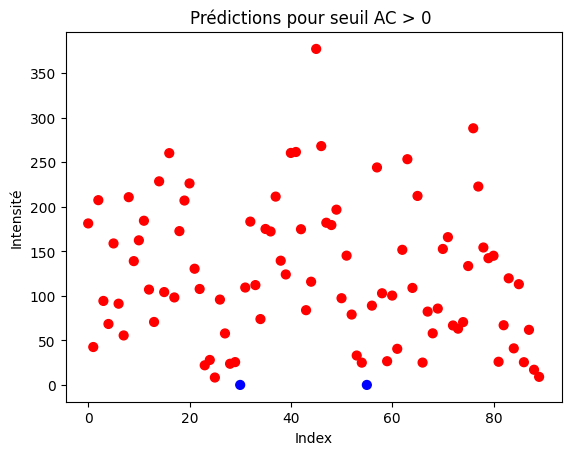

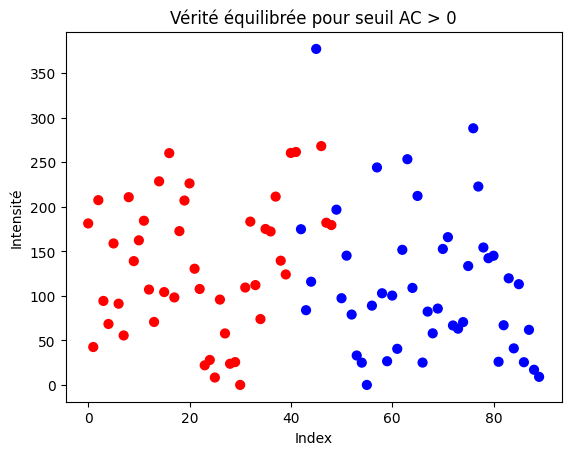

F1 score non mouvement:  0.0425531914893617
F1 score mouvement :  0.6616541353383458
Accuracy pour seuil > 0 : 0.50


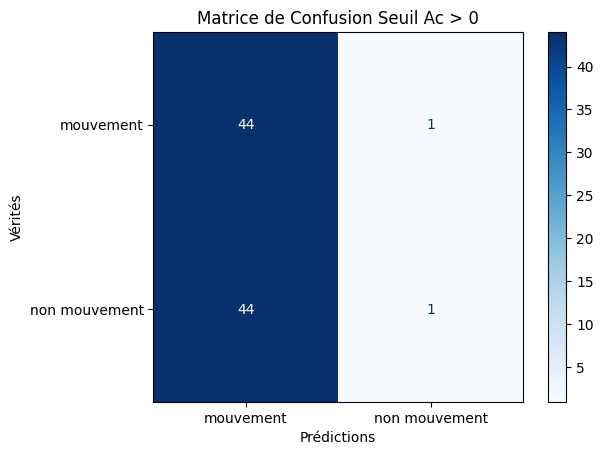

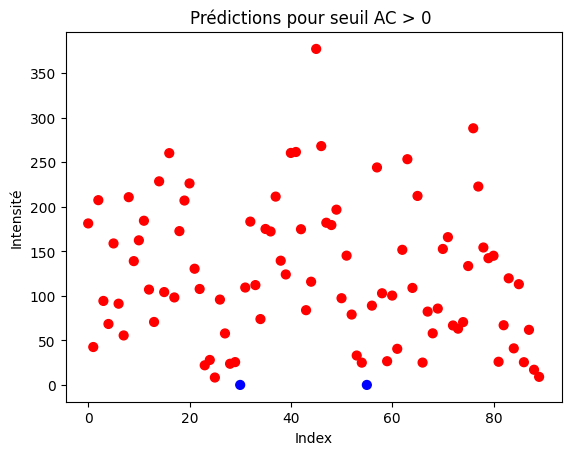

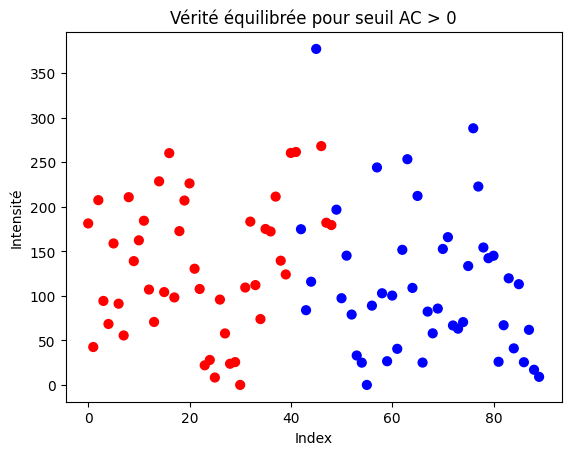

F1 score non mouvement:  0.0425531914893617
F1 score mouvement :  0.6616541353383458
Accuracy pour seuil > 0 : 0.50


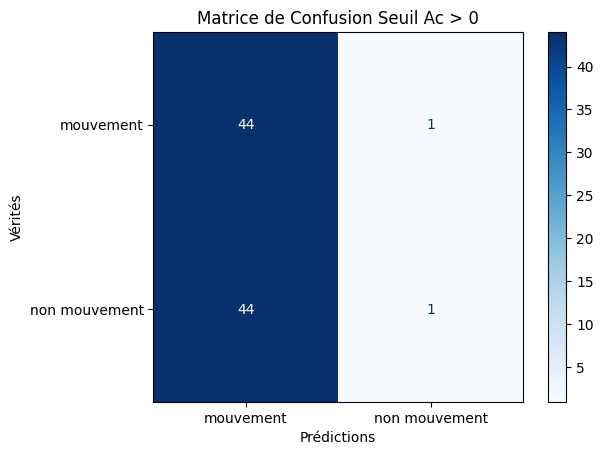

In [37]:
balanced_X_members = [X_flat, X_flat]
balanced_Y_members = [Y_flat, Y_flat]

for idx_members in range(2):
    #On a X_dom et Y_dom : construire un Y_pred et le comparer à Y_dom
    Y_pred_0 = []

    for idx_data in range(0,len(balanced_X_members[idx_members])):
        seuil = balanced_X_members[idx_members][idx_data]
        if seuil > 0 :
            Y_pred_0.append("mouvement")
        elif seuil == 0 :
            Y_pred_0.append("non mouvement")
        else:
            Y_pred_0.append(None)
            
    # -------------------------------------------- Prédictions -------------------------------------
    colors = []
    # Créer un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in Y_pred_0]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(balanced_X_members[idx_members])), balanced_X_members[idx_members], c=colors, s=40)
    plt.title("Prédictions pour seuil AC > 0 ")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()

    # ------------------------------------------- Vérité --------------------------------------
    # Créer un mapping de couleur pour chaque label
    label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
    colors = [label_to_color[y] for y in balanced_Y_members[idx_members]]
    # Affichage : index en abscisse, intensité en ordonnée
    plt.scatter(range(len(balanced_X_members[idx_members])), balanced_X_members[idx_members], c=colors, s=40)
    plt.title("Vérité équilibrée pour seuil AC > 0")
    plt.xlabel("Index")
    plt.ylabel("Intensité")
    plt.show()



    # ------------------------------------------- Evaluate the model ---------------------------------------
    # F1 score
    f1score_mouvement = f1_score(balanced_Y_members[idx_members], Y_pred_0, labels = ["non mouvement","mouvement"], pos_label = "mouvement")
    f1score_non_mouvement = f1_score(balanced_Y_members[idx_members], Y_pred_0, labels = ["non mouvement","mouvement"], pos_label = "non mouvement")
    print("F1 score non mouvement: ", f1score_non_mouvement)
    print("F1 score mouvement : ", f1score_mouvement)

    # Accuracy
    accuracy = accuracy_score(balanced_Y_members[idx_members], Y_pred_0)
    print(f"Accuracy pour seuil > 0 : {accuracy:.2f}")
    cm_75 = confusion_matrix(balanced_Y_members[idx_members], Y_pred_0)

    # Afficher la matrice de confusion
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_75, display_labels= ["mouvement", "non mouvement"])
    disp.plot(cmap="Blues")
    disp.ax_.set_title("Matrice de Confusion Seuil Ac > 0")
    disp.ax_.set_xlabel("Prédictions")
    disp.ax_.set_ylabel("Vérités")
    plt.show()